In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind, chi2_contingency

In [23]:
data = pd.read_csv("dataset/hiv-attitudes_national_tls.csv")

data

,ISO3,DataId,Indicator,Value,Precision,DHS_CountryCode,CountryName,SurveyYear,SurveyId,IndicatorId,...,IsPreferred,SDRID,RegionId,SurveyYearLabel,SurveyType,DenominatorWeighted,DenominatorUnweighted,CILow,CIHigh,LevelRank
0,#country+code,#meta+id,#indicator+name,#indicator+value+num,#indicator+precision,NaN,#country+name,#date+year,#survey+id,#indicator+code,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TLS,461070,Accepting attitudes - Willing to care for fami...,55,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_CRE,...,1.0,HAAATTWCRE,NaN,2009-10,DHS,5748.0,5397.0,NaN,NaN,NaN
2,TLS,461071,Accepting attitudes - Would buy fresh vegetabl...,34.2,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_VEG,...,1.0,HAAATTWVEG,NaN,2009-10,DHS,5748.0,5397.0,NaN,NaN,NaN
3,TLS,461073,Accepting attitudes - Female teacher who is HI...,44.2,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_FTC,...,1.0,HAAATTWFTC,NaN,2009-10,DHS,5748.0,5397.0,NaN,NaN,NaN
4,TLS,461072,Accepting attitudes - Not secretive about fami...,84.1,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_SEC,...,1.0,HAAATTWSEC,NaN,2009-10,DHS,5748.0,5397.0,NaN,NaN,NaN
5,TLS,461104,Accepting attitudes towards those living with ...,11.1,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_AAT,...,1.0,HAAATTWAAT,NaN,2009-10,DHS,5748.0,5397.0,NaN,NaN,NaN
6,TLS,468218,Number of women who have heard of AIDS,5748,0,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_NUM,...,1.0,HAAATTWNUM,NaN,2009-10,DHS,NaN,5397.0,NaN,NaN,NaN
7,TLS,285178,Number of women who have heard of AIDS (unweig...,5397,0,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_UNW,...,1.0,HAAATTWUNW,NaN,2009-10,DHS,5748.0,NaN,NaN,NaN,NaN
8,TLS,687147,Accepting attitudes - Willing to care for fami...,26.4,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_M_CRE,...,1.0,HAAATTMCRE,NaN,2009-10,DHS,2474.0,2442.0,NaN,NaN,NaN
9,TLS,687148,Accepting attitudes - Would buy fresh vegetabl...,21.8,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_M_VEG,...,1.0,HAAATTMVEG,NaN,2009-10,DHS,2474.0,2442.0,NaN,NaN,NaN


In [24]:
data.drop(['RegionId', 'CILow', 'ByVariableLabel', 'CIHigh', 'LevelRank'], axis=1, inplace=True)

data

,ISO3,DataId,Indicator,Value,Precision,DHS_CountryCode,CountryName,SurveyYear,SurveyId,IndicatorId,...,CharacteristicCategory,CharacteristicLabel,ByVariableId,IsTotal,IsPreferred,SDRID,SurveyYearLabel,SurveyType,DenominatorWeighted,DenominatorUnweighted
0,#country+code,#meta+id,#indicator+name,#indicator+value+num,#indicator+precision,NaN,#country+name,#date+year,#survey+id,#indicator+code,...,NaN,NaN,#indicator+label+code,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TLS,461070,Accepting attitudes - Willing to care for fami...,55,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_CRE,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWCRE,2009-10,DHS,5748.0,5397.0
2,TLS,461071,Accepting attitudes - Would buy fresh vegetabl...,34.2,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_VEG,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWVEG,2009-10,DHS,5748.0,5397.0
3,TLS,461073,Accepting attitudes - Female teacher who is HI...,44.2,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_FTC,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWFTC,2009-10,DHS,5748.0,5397.0
4,TLS,461072,Accepting attitudes - Not secretive about fami...,84.1,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_SEC,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWSEC,2009-10,DHS,5748.0,5397.0
5,TLS,461104,Accepting attitudes towards those living with ...,11.1,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_AAT,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWAAT,2009-10,DHS,5748.0,5397.0
6,TLS,468218,Number of women who have heard of AIDS,5748,0,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_NUM,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWNUM,2009-10,DHS,NaN,5397.0
7,TLS,285178,Number of women who have heard of AIDS (unweig...,5397,0,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_W_UNW,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTWUNW,2009-10,DHS,5748.0,NaN
8,TLS,687147,Accepting attitudes - Willing to care for fami...,26.4,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_M_CRE,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTMCRE,2009-10,DHS,2474.0,2442.0
9,TLS,687148,Accepting attitudes - Would buy fresh vegetabl...,21.8,1,TL,Timor-Leste,2009,TL2009DHS,HA_AATT_M_VEG,...,Total 15-49,Total 15-49,0,1.0,1.0,HAAATTMVEG,2009-10,DHS,2474.0,2442.0


In [25]:
# Quick overview
print(data.shape)               # hodi haree ukuran dataset (lina, coluna)
print(data.columns.tolist())    # hodi fo sai naran koluna ka variable sira ho forma lista ida


(35, 24)
['ISO3', 'DataId', 'Indicator', 'Value', 'Precision', 'DHS_CountryCode', 'CountryName', 'SurveyYear', 'SurveyId', 'IndicatorId', 'IndicatorOrder', 'IndicatorType', 'CharacteristicId', 'CharacteristicOrder', 'CharacteristicCategory', 'CharacteristicLabel', 'ByVariableId', 'IsTotal', 'IsPreferred', 'SDRID', 'SurveyYearLabel', 'SurveyType', 'DenominatorWeighted', 'DenominatorUnweighted']


### Cleaning: ensure Value numeric and parse SurveyYear to numeric year

In [26]:

data['Value'] = pd.to_numeric(data['Value'], errors='coerce')

data['SurveyYearNum'] = (
    data['SurveyYear']
    .astype(str)
    .str.extract(r'(\d{4})')
    .astype(float)
)

data = data.dropna(subset=['Value', 'SurveyYearNum']).reset_index(drop=True)

# Show info
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ISO3                    34 non-null     object 
 1   DataId                  34 non-null     object 
 2   Indicator               34 non-null     object 
 3   Value                   34 non-null     float64
 4   Precision               34 non-null     object 
 5   DHS_CountryCode         34 non-null     object 
 6   CountryName             34 non-null     object 
 7   SurveyYear              34 non-null     object 
 8   SurveyId                34 non-null     object 
 9   IndicatorId             34 non-null     object 
 10  IndicatorOrder          34 non-null     float64
 11  IndicatorType           34 non-null     object 
 12  CharacteristicId        34 non-null     float64
 13  CharacteristicOrder     34 non-null     float64
 14  CharacteristicCategory  34 non-null     obje

In [27]:
s = data['Indicator'].str.lower()

data['IndicatorType'] = np.select(
    [s.str.contains('accepting attitudes'),
     s.str.contains('justified.*(sexual|condom|sti)'),
     s.str.contains('heard of aids'),
     s.str.startswith('number of')],
    ['AcceptingAttitude','SexualBehaviour','Knowledge','Denominator'],
    'Other'
)

data['Sex'] = np.select(
    [s.str.contains('\[women\]'), s.str.contains('\[men\]')],
    ['Women','Men'],
    'Unknown'
)

display(data['IndicatorType'].value_counts())
display(data.groupby(['IndicatorType','Sex']).size().unstack(fill_value=0))

<>:13: SyntaxWarning: invalid escape sequence '\['
<>:13: SyntaxWarning: invalid escape sequence '\['
<>:13: SyntaxWarning: invalid escape sequence '\['
<>:13: SyntaxWarning: invalid escape sequence '\['
C:\Users\Valente\AppData\Local\Temp\ipykernel_10780\1444696480.py:13: SyntaxWarning: invalid escape sequence '\['
  [s.str.contains('\[women\]'), s.str.contains('\[men\]')],
C:\Users\Valente\AppData\Local\Temp\ipykernel_10780\1444696480.py:13: SyntaxWarning: invalid escape sequence '\['
  [s.str.contains('\[women\]'), s.str.contains('\[men\]')],
C:\Users\Valente\AppData\Local\Temp\ipykernel_10780\1444696480.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  s.str.contains('justified.*(sexual|condom|sti)'),


IndicatorType
AcceptingAttitude    12
Knowledge             8
Denominator           8
SexualBehaviour       6
Name: count, dtype: int64

Sex,Men,Unknown,Women
IndicatorType,,,
AcceptingAttitude,6,0,6
Denominator,0,8,0
Knowledge,0,8,0
SexualBehaviour,3,0,3


iha ami nia dataset ne'e ami sei analyza buat tolu ne'e mak:
- Accepting Attitudes Indicators

# Filter Accepting Attitude indicators

In [28]:

data_accept = data[data['IndicatorType']=='AcceptingAttitude'].copy()
print("Rows (accepting):", data_accept.shape[0])
data_accept[['Indicator','SurveyYear','SurveyYearNum','Sex','Value']]


Rows (accepting): 12


,Indicator,SurveyYear,SurveyYearNum,Sex,Value
0,Accepting attitudes - Willing to care for fami...,2009,2009.0,Women,55.0
1,Accepting attitudes - Would buy fresh vegetabl...,2009,2009.0,Women,34.2
2,Accepting attitudes - Female teacher who is HI...,2009,2009.0,Women,44.2
3,Accepting attitudes - Not secretive about fami...,2009,2009.0,Women,84.1
4,Accepting attitudes towards those living with ...,2009,2009.0,Women,11.1
7,Accepting attitudes - Willing to care for fami...,2009,2009.0,Men,26.4
8,Accepting attitudes - Would buy fresh vegetabl...,2009,2009.0,Men,21.8
9,Accepting attitudes - Female teacher who is HI...,2009,2009.0,Men,27.8
10,Accepting attitudes - Not secretive about fami...,2009,2009.0,Men,87.3
11,Accepting attitudes towards those living with ...,2009,2009.0,Men,3.4


# CELL 6: Descriptive statistics for Accepting Attitudes

In [29]:

# Mean by indicator
accept_by_indicator = data_accept.groupby('Indicator')['Value'].mean().sort_values(ascending=False)
display(accept_by_indicator)

# Mean by Sex
accept_by_sex = data_accept.groupby('Sex')['Value'].mean()
display(accept_by_sex)

# Mean by Year
accept_by_year = data_accept.groupby('SurveyYearNum')['Value'].mean()
display(accept_by_year)


Indicator
Accepting attitudes - Not secretive about family member's HIV status (4) [Men]                                                87.30
Accepting attitudes - Not secretive about family member's HIV status (4) [Women]                                              84.10
Accepting attitudes - Willing to care for family member sick with AIDS (1) [Women]                                            55.00
Accepting attitudes - Female teacher who is HIV+ but not sick should be allowed to continue teaching in school (3) [Women]    44.20
Accepting attitudes - Female teacher who is HIV+ but not sick should be allowed to continue teaching in school (3) [Men]      27.80
Accepting attitudes - Willing to care for family member sick with AIDS (1) [Men]                                              26.40
Accepting attitudes - Would buy fresh vegetables from a shopkeeper with AIDS (2) [Women]                                      22.25
Accepting attitudes - Would buy fresh vegetables from a shopkeeper

Sex
Men      30.333333
Women    39.816667
Name: Value, dtype: float64

SurveyYearNum
2009.0    39.53
2016.0    12.80
Name: Value, dtype: float64

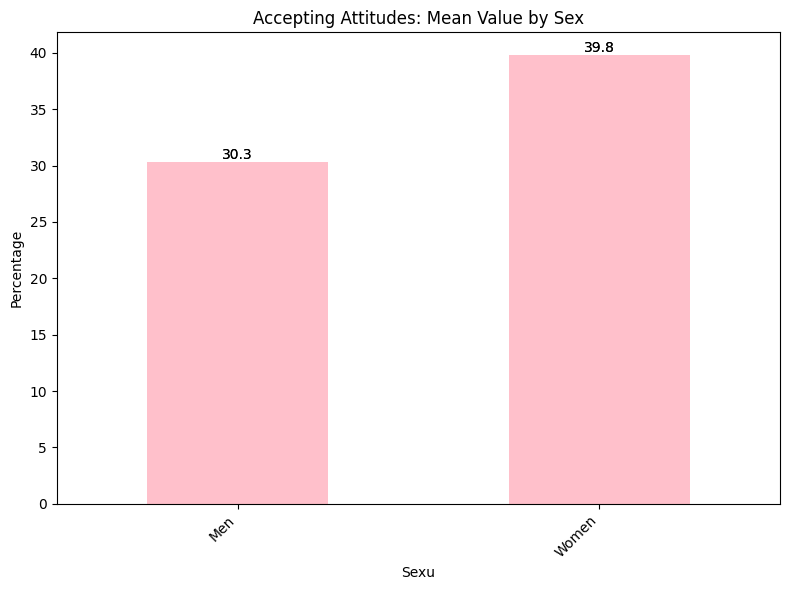

In [30]:
# Bar chart: mean by indicator
plt.figure(figsize=(8,6))
ax = accept_by_sex.plot(kind='bar', color='pink')
accept_by_sex.plot(kind='bar', color='pink')
plt.title('Accepting Attitudes: Mean Value by Sex')
plt.ylabel('Percentage')
plt.xlabel('Sexu')
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',      # format angka (1 desimal)
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

C:\Users\Valente\AppData\Local\Temp\ipykernel_10780\1448225322.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


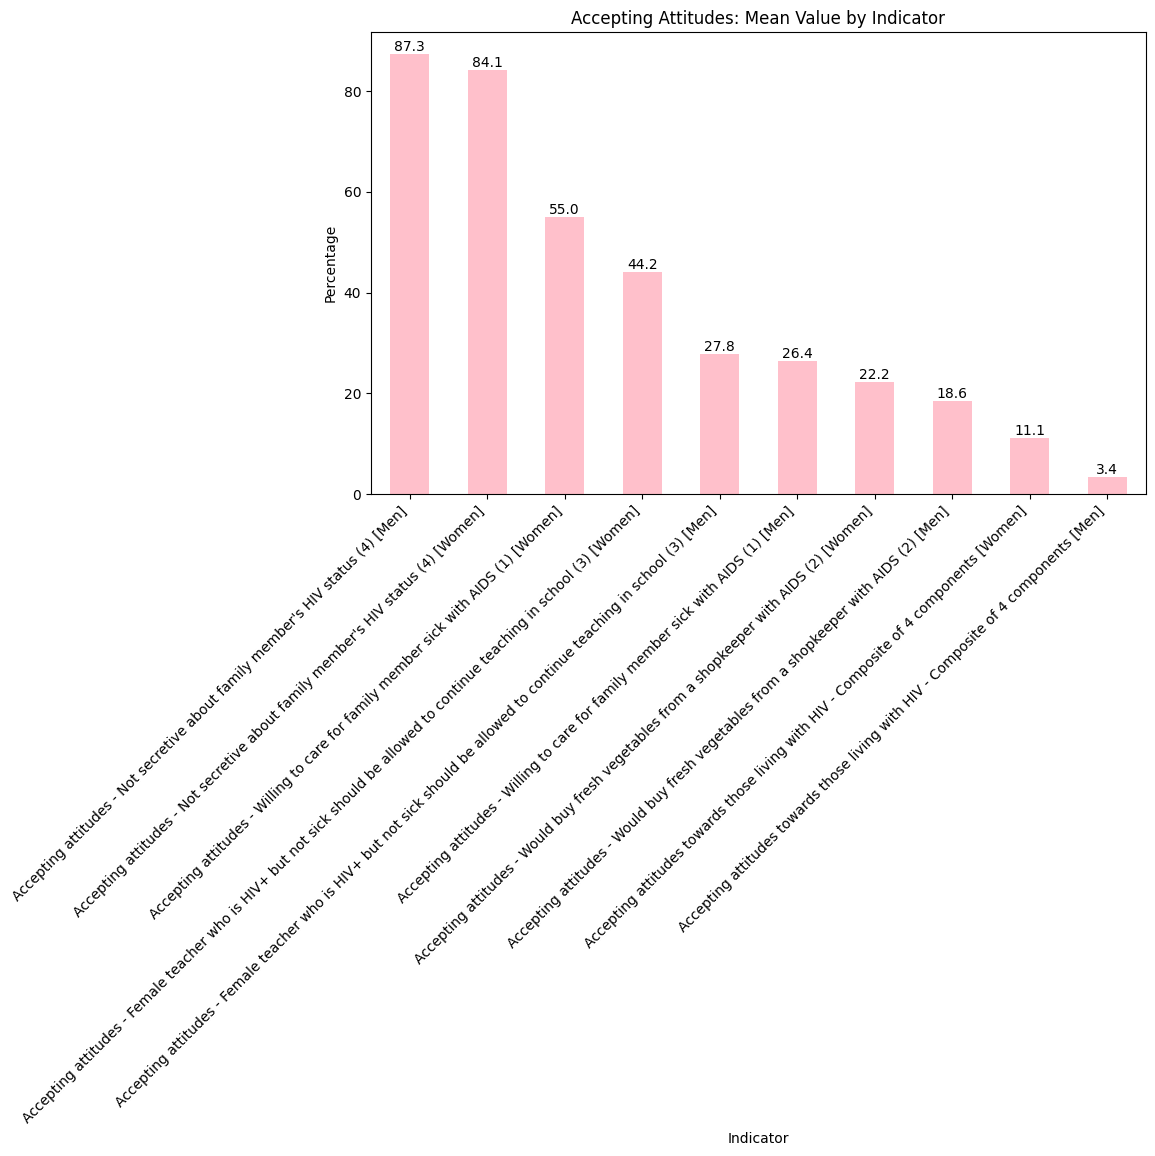

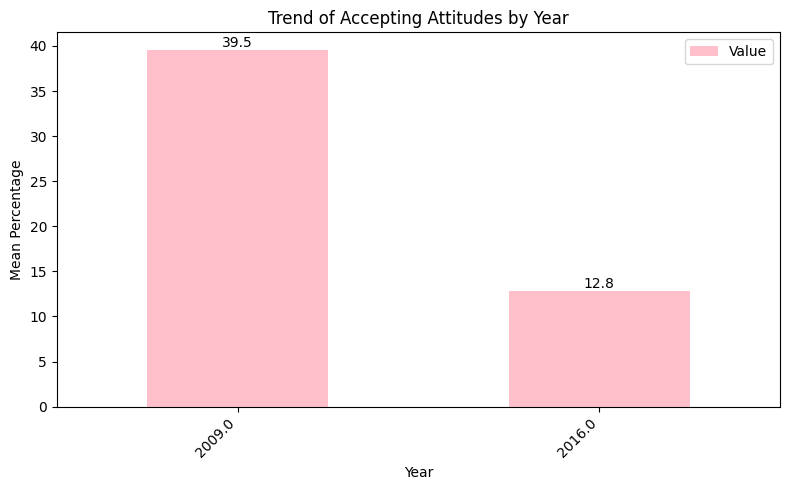

SurveyYearNum
2009.0    39.53
2016.0    12.80
Name: Value, dtype: float64

In [31]:
# CELL 7: Plots (matplotlib only)
plt.figure(figsize=(10,6))
ax = accept_by_indicator.plot(kind='bar', color='pink')
# Bar chart: mean by indicator

plt.title('Accepting Attitudes: Mean Value by Indicator')
plt.ylabel('Percentage')
plt.xlabel('Indicator')
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',      # format angka (1 desimal)
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

# Trend by Sex: mean per year for each sex
plt.figure(figsize=(8,5))
ax = accept_by_year.plot(kind='bar', color='pink')
plt.title('Trend of Accepting Attitudes by Year')
plt.xlabel('Year')
plt.ylabel('Mean Percentage')
plt.legend()

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',      # format angka (1 desimal)
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

data_accept.groupby('SurveyYearNum')['Value'].mean()



tamba ida ne'e ami haree liu ba iha 2009 no 2016 entaun ami konklui katak accepting attitude sira ne'e sei tun" kada tinan to 2016 ne'e hela accepting ida deit ne'e mak sira hola modo husi ema ne'ebe hetan moras HIV/SIDA

# T-test comparing Men vs Women across AcceptingAttitude indicator values

In [32]:

men_accept = data_accept[data_accept['Sex']=='Men']['Value'].dropna()
women_accept = data_accept[data_accept['Sex']=='Women']['Value'].dropna()

print("n_men:", len(men_accept), "n_women:", len(women_accept))

if len(men_accept)>0 and len(women_accept)>0:
    t_stat, p_val = ttest_ind(women_accept, men_accept, equal_var=False, nan_policy='omit')
    print("t-statistic:", t_stat, "p-value:", p_val)
else:
    print("Not enough data for t-test.")


n_men: 6 n_women: 6
t-statistic: 0.5725782865892387 p-value: 0.579597921650794


# Chi-square on counts of Positive vs NotPositive (threshold 50%)

In [33]:

data_accept['AcceptCategory'] = data_accept['Value'].apply(lambda x: 'Positive' if x >50 else 'NotPositive')
cont_table = pd.crosstab(data_accept['SurveyYearNum'], data_accept['AcceptCategory'])
display(cont_table)

if cont_table.shape[0]>0 and cont_table.shape[1]>0:
    chi2, p, dof, expected = chi2_contingency(cont_table)
    print("Chi2:", chi2, "p-value:", p, "dof:", dof)
else:
    print("Not enough cells for chi-square.")


AcceptCategory,NotPositive,Positive
SurveyYearNum,,
2009.0,7,3
2016.0,2,0


Chi2: 0.0 p-value: 1.0 dof: 1


# Regression (OLS) with indicator fixed effects to estimate year effect

In [34]:

years_sorted = sorted(data['SurveyYearNum'].unique())
if len(years_sorted) >= 2:
    first, last = years_sorted[0], years_sorted[-1]
    data['YearDummyLast'] = (data['SurveyYearNum']==last).astype(int)
    reg_data = data[data['IndicatorType']=='AcceptingAttitude'].copy()
    # Fit OLS with Indicator fixed effects
    model = smf.ols('Value ~ YearDummyLast + C(Indicator)', data=reg_data).fit()
    print(model.summary())
else:
    print("Not enough years for regression.")


                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     11.13
Date:                Thu, 18 Dec 2025   Prob (F-statistic):              0.229
Time:                        13:42:43   Log-Likelihood:                -28.078
No. Observations:                  12   AIC:                             78.16
Df Residuals:                       1   BIC:                             83.49
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                                                                                                 coef    std err          t      P>|t|      [0.025      0.975]
---

# Filter sexual behaviour indicators

In [35]:

# data_sex = data[data['IndicatorType']=='SexualBehaviour'].copy()
# data_sex[['Indicator','SurveyYear','Sex','Value']]

# # Descriptive
# display(data_sex.groupby('Indicator')['Value'].describe())
# display(data_sex.groupby('Sex')['Value'].mean())
# display(data_sex.groupby('SurveyYearNum')['Value'].mean())


In [36]:
# # CELL 12: Plot sexual behaviour means by indicator
# plt.figure(figsize=(10,5))
# sex_mean = data_sex.groupby('Indicator')['Value'].mean().sort_values(ascending=False)
# sex_mean.plot(kind='bar', color='pink')
# plt.title('Sexual Behaviour Indicators: Mean Value by Indicator')
# plt.ylabel('Percentage')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()


In [37]:
# # CELL 13: T-test for specific sexual behaviour indicator (refusing sex)
# # Use substring match
# refuse_w = data[data['Indicator'].str.lower().str.contains('refusing to have sexual intercourse') & (data['Sex']=='Women')]['Value'].dropna()
# refuse_m = data[data['Indicator'].str.lower().str.contains('refusing to have sexual intercourse') & (data['Sex']=='Men')]['Value'].dropna()

# print("n_women_refuse:", len(refuse_w), "n_men_refuse:", len(refuse_m))
# if len(refuse_w)>0 and len(refuse_m)>0:
#     t_stat_ref, p_ref = ttest_ind(refuse_w, refuse_m, equal_var=False, nan_policy='omit')
#     print("t:", t_stat_ref, "p:", p_ref)
# else:
#     print("Not enough data for refuse-sex t-test.")


<!-- # CELL 14: Denominator analysis -->

In [38]:

# data_den = data[data['IndicatorType']=='Denominator'].copy()
# display(data_den[['Indicator','SurveyYear','DenominatorWeighted','DenominatorUnweighted']].drop_duplicates().sort_values('SurveyYear'))

# # Summary of denominators across dataset
# display(data[['SurveyYearNum','DenominatorWeighted','DenominatorUnweighted']].drop_duplicates().sort_values('SurveyYearNum'))


In [39]:
# # CELL 15: Plot DenominatorWeighted by Year
# plt.figure(figsize=(8,4))
# den_by_year = data.groupby('SurveyYearNum')['DenominatorWeighted'].first().dropna()
# if not den_by_year.empty:
#     den_by_year.plot(kind='bar', color='pink')
#     plt.title('Denominator (Weighted) by Survey Year')
#     plt.xlabel('Year')
#     plt.ylabel('DenominatorWeighted')
#     plt.tight_layout()
#     plt.show()
# else:
#     print("No denominator values available for plotting.")


In [40]:
# # CELL 16: Build change summary for Accepting Attitudes between first and last year (if possible)
# years_sorted = sorted(data_accept['SurveyYearNum'].unique())
# if len(years_sorted) >= 2:
#     first, last = years_sorted[0], years_sorted[-1]
#     pivot = data_accept.pivot_table(values='Value', index='Indicator', columns='SurveyYearNum')
#     if first in pivot.columns and last in pivot.columns:
#         change = pivot[last] - pivot[first]
#         summary_change = pd.DataFrame({
#             f'value_{first}': pivot[first],
#             f'value_{last}': pivot[last],
#             'change': change
#         }).sort_values('change', ascending=False).reset_index()
#         display(summary_change.head(20))
#         # Save CSV for use in slides
#         print("Saved summary to /mnt/data/accepting_attitudes_change_summary.csv")
#     else:
#         print("Pivot does not contain both years.")
# else:
#     print("Not enough years in accepting attitudes for change summary.")


In [41]:
# # CELL 17: Prepare a few text strings you can paste into slides
# text_intro = """
# Data: DHS Timor-Leste — Attitudes toward people living with HIV.
# Analisis: Descriptive, t-test (Men vs Women), chi-square (change in positive proportion), and regression with indicator fixed effects.
# Catatan: Data ini summary-level (persentase indikator per tahun), bukan microdata individu.
# """
# print(text_intro)

# # Short conclusions template (fill numbers after running)
# concl = """
# 1. Indikator accepting attitudes tertinggi: [nama indikator] = [nilai]%.
# 2. Indikator accepting attitudes terendah: [nama indikator] = [nilai]%.
# 3. Rata-rata accepting attitudes (Women) = [X]%, (Men) = [Y]%.
# 4. Hasil t-test Men vs Women: p = [p-value] → [interpretation].
# 5. Chi-square untuk perubahan proporsi positive antar tahun: p = [p-value] → [interpretation].
# 6. Regresi fixed effects: koefisien YearDummyLast = [coef], p = [p-val] → [interpretation].
# """
# print(concl)
